In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("ad_spend.csv")
df.head()

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [4]:
df.isnull().sum()

Ad Spend ($)    0
Season          0
Revenue ($)     0
dtype: int64

In [12]:
# Plot graph between avg Ad spend and Revenue Season wise
season_wise = df.groupby("Season")[["Ad Spend ($)","Revenue ($)"]].mean()
season_wise

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


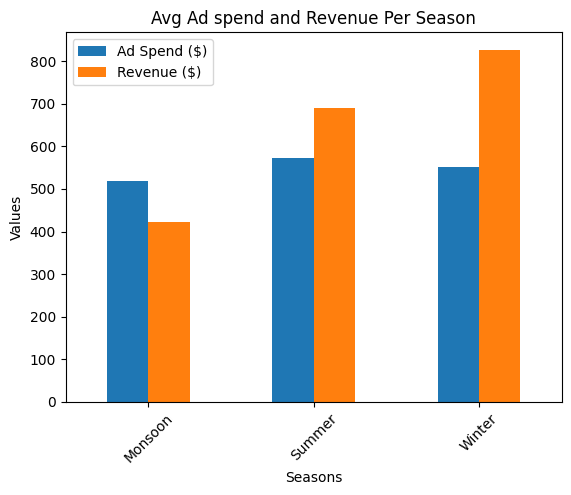

In [23]:
season_wise.plot(kind="bar")
plt.xlabel("Seasons")
plt.ylabel("Values")
plt.title("Avg Ad spend and Revenue Per Season")
plt.xticks(rotation = 45)
plt.show()

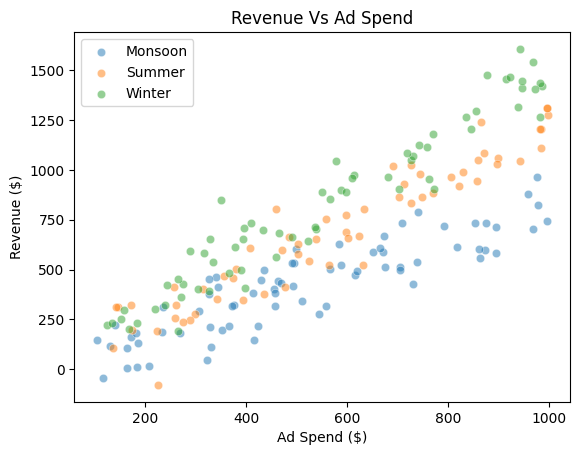

In [54]:
# Now let's check relationship betweeen these two using scatter plot
for season,subdf in df.groupby("Season"):
    sns.scatterplot(x = subdf["Ad Spend ($)"], y=subdf["Revenue ($)"], alpha = 0.5, label = season)
    
plt.title("Revenue Vs Ad Spend")
plt.show()

## Data preprocessing:

In [59]:
# One Hot enoding:
df = pd.get_dummies(df, columns = ["Season"], drop_first=True)
df.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [69]:
# Define Features and Target Variable
X = df.drop("Revenue ($)", axis = 1)
y = df["Revenue ($)"]

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=10)

# Model Training:

## Using Linear Regression:

In [70]:
model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.8823172485530336

## Using Decision Tree Regressor:

In [71]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9163405765229717

## Using Gradient Boosting:

In [72]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9259528125552984

In [79]:
# Checking predcited vs actual
y_pred = model.predict(X_test)

comp = pd.DataFrame({"Actual": y_test, "predicted" : y_pred})
comp.head()

,Actual,predicted
59,605,668.066269
5,1125,1052.139051
20,699,637.091195
198,504,434.483700
52,1310,1251.627118


In [81]:
# Making new diff % column

comp["diff %"] = abs(((comp["Actual"] - comp["predicted"])*100)/(comp["Actual"]))

comp.head()                                                             

,Actual,predicted,diff %
59,605,668.066269,10.424177
5,1125,1052.139051,6.476529
20,699,637.091195,8.856767
198,504,434.483700,13.792917
52,1310,1251.627118,4.455945
